# Prerequisites · M4 — Information Theory for Deep Learning

> **Goal:** the three quantities that define most deep-learning losses — **entropy**, **cross-entropy**, and **KL divergence** — from scratch, so that cross-entropy stops being a formula and becomes "the distance between the true distribution and the model's."

**Why.** The most-used loss in all of deep learning is **cross-entropy** (every classifier, every language model). The **KL divergence** is the regularizer in VAEs (NB23) and the leash in RLHF (NB21), and the target in distillation (NB30). **Perplexity** — how language models are reported — is just exponentiated cross-entropy. All of it comes from three ideas about *information* and *surprise*, which we build here.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)


## 1. Entropy — the average surprise of a distribution

The **surprise** of an outcome with probability $p$ is $-\log p$: certain events ($p=1$) carry zero surprise; rare events carry a lot. **Entropy** is the *average* surprise of a distribution:
$$H(p) = -\sum_i p_i \log p_i.$$
It measures **uncertainty**: a fair coin (maximally unpredictable) has the highest entropy; a biased coin (predictable) has less; a certain outcome has zero. With $\log_2$ the unit is **bits** (the average number of yes/no questions to identify the outcome); with $\ln$ it's **nats** (what DL uses). Entropy is also the *irreducible* loss floor — no model can predict better than the data's own entropy.


fair coin  [0.5,0.5] : 1.000 bits (max uncertainty)
biased     [0.9,0.1] : 0.469 bits (more predictable)
certain    [1.0,0.0] : -0.000 bits (no surprise)


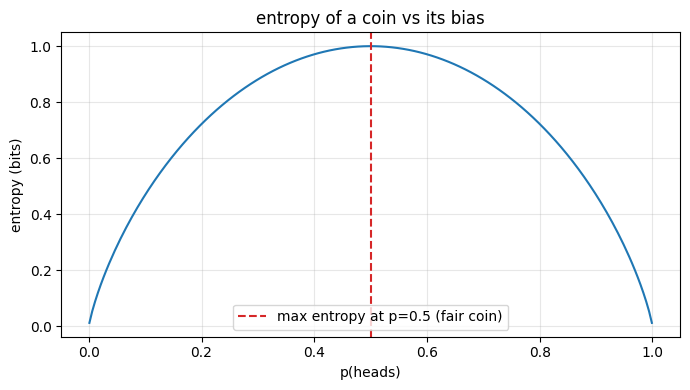

In [2]:
def entropy(p, base=np.e):
    p = np.array(p); p = p[p>0]                 # 0·log0 = 0
    return -np.sum(p*np.log(p))/np.log(base)

print(f"fair coin  [0.5,0.5] : {entropy([0.5,0.5],2):.3f} bits (max uncertainty)")
print(f"biased     [0.9,0.1] : {entropy([0.9,0.1],2):.3f} bits (more predictable)")
print(f"certain    [1.0,0.0] : {entropy([1.0,0.0],2):.3f} bits (no surprise)")

ps = np.linspace(0.001,0.999,200)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ps, [entropy([p,1-p],2) for p in ps], color="tab:blue")
ax.axvline(0.5, ls="--", color="tab:red", label="max entropy at p=0.5 (fair coin)")
ax.set_title("entropy of a coin vs its bias"); ax.set_xlabel("p(heads)"); ax.set_ylabel("entropy (bits)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**↳ Used in:** the "irreducible loss" $L_\infty$ in scaling laws (NB18) is the data's entropy; a language model's best-possible loss is the entropy of the text.


## 2. Cross-entropy — coding one distribution with another's code

**Cross-entropy** measures the average surprise of outcomes drawn from the *true* distribution $p$, but scored using the *model's* distribution $q$:
$$H(p,q) = -\sum_i p_i \log q_i.$$
Intuition: it's the cost of using $q$'s "codebook" to describe data that actually follows $p$. A key inequality: $H(p,q) \ge H(p)$, with **equality only when $q=p$**. So *minimizing cross-entropy pushes the model $q$ toward the truth $p$* — which is exactly what training a classifier does. When $p$ is a one-hot label, $H(p,q) = -\log q_{\text{true class}}$, the familiar per-example loss.


In [3]:
def cross_entropy(p, q):
    p, q = np.array(p), np.array(q)
    return -np.sum(p*np.log(q + 1e-12))

p = np.array([0.7, 0.2, 0.1])                    # "true" distribution
print(f"H(p)              = {entropy(p):.4f}  (the floor)")
print(f"H(p, q=p)         = {cross_entropy(p, p):.4f}  (equals H(p) when q matches p)")
print(f"H(p, q=[.3,.3,.4])= {cross_entropy(p,[.3,.3,.4]):.4f}  (a wrong q costs more)")

# one-hot label case: cross-entropy = -log(prob of true class)
onehot = np.array([0,1,0]); q = np.array([0.1,0.8,0.1])
print(f"\none-hot label, model q=[.1,.8,.1]: CE = -log(q_true) = {cross_entropy(onehot,q):.4f} = {-np.log(0.8):.4f}")


H(p)              = 0.8018  (the floor)
H(p, q=p)         = 0.8018  (equals H(p) when q matches p)
H(p, q=[.3,.3,.4])= 1.1752  (a wrong q costs more)

one-hot label, model q=[.1,.8,.1]: CE = -log(q_true) = 0.2231 = 0.2231


**↳ Used in:** `F.cross_entropy` in *every* classifier and language model (NB02, NB06, NB07, NB11); the softmax-cross-entropy `p−y` gradient you derived in NB02.


## 3. KL divergence — the "extra bits" from being wrong

The **Kullback–Leibler divergence** is the *gap* between cross-entropy and entropy — the extra cost of using $q$ instead of the true $p$:
$$D_{\mathrm{KL}}(p\,\|\,q) = H(p,q) - H(p) = \sum_i p_i \log\frac{p_i}{q_i}.$$
Properties: $D_{\mathrm{KL}} \ge 0$ always (Gibbs' inequality), $=0$ iff $p=q$, and it's **asymmetric** ($D(p\|q)\ne D(q\|p)$) — so it's a "divergence," not a true distance. Since $H(p)$ doesn't depend on the model, **minimizing cross-entropy = minimizing KL$(p\|q)$ = making the model match the data.** That's the unifying statement: cross-entropy loss *is* KL minimization.


In [4]:
def kl(p, q):
    p, q = np.array(p), np.array(q)
    return np.sum(p*np.log((p+1e-12)/(q+1e-12)))

p = np.array([0.7,0.2,0.1]); q = np.array([0.3,0.3,0.4])
print(f"H(p,q) = {cross_entropy(p,q):.4f}")
print(f"H(p)   = {entropy(p):.4f}")
print(f"KL(p‖q)= {kl(p,q):.4f}   (= H(p,q) − H(p) = {cross_entropy(p,q)-entropy(p):.4f})  ✓")
print(f"KL(p‖p)= {kl(p,p):.4f}   (zero when identical)")
print(f"KL(q‖p)= {kl(q,p):.4f}   (≠ KL(p‖q): asymmetric!)")
assert kl(p,q) >= 0 and abs(kl(p,p)) < 1e-9
print("\n✅ KL ≥ 0, zero iff equal, asymmetric — and cross-entropy = H(p) + KL(p‖q)")


H(p,q) = 1.1752
H(p)   = 0.8018
KL(p‖q)= 0.3734   (= H(p,q) − H(p) = 0.3734)  ✓
KL(p‖p)= 0.0000   (zero when identical)
KL(q‖p)= 0.4220   (≠ KL(p‖q): asymmetric!)

✅ KL ≥ 0, zero iff equal, asymmetric — and cross-entropy = H(p) + KL(p‖q)


**↳ Used in:** the VAE's regularizer $D_{\mathrm{KL}}(q(z|x)\|\mathcal{N}(0,I))$ (NB23); the RLHF/DPO KL-to-reference leash $\beta\,\mathrm{KL}(\pi\|\pi_{\text{ref}})$ (NB21); distillation matches student to teacher via KL (NB30).


## 4. Forward vs reverse KL — mode-covering vs mode-seeking

Because KL is asymmetric, *which way you write it matters*. Fitting a simple $q$ (a single Gaussian) to a complex bimodal $p$:
- **Forward KL** $D(p\|q)$ ("mean-seeking / mode-covering"): $q$ spreads to cover *all* of $p$'s mass — it won't ignore a mode, but it puts mass in the empty middle. This is what maximum-likelihood / cross-entropy does.
- **Reverse KL** $D(q\|p)$ ("mode-seeking"): $q$ locks onto *one* mode and ignores the others — it avoids the empty regions. This is what variational inference (VAEs) and some RL objectives use.

Knowing which KL you're minimizing predicts the failure mode (blurry averages vs mode collapse). Let's see it.


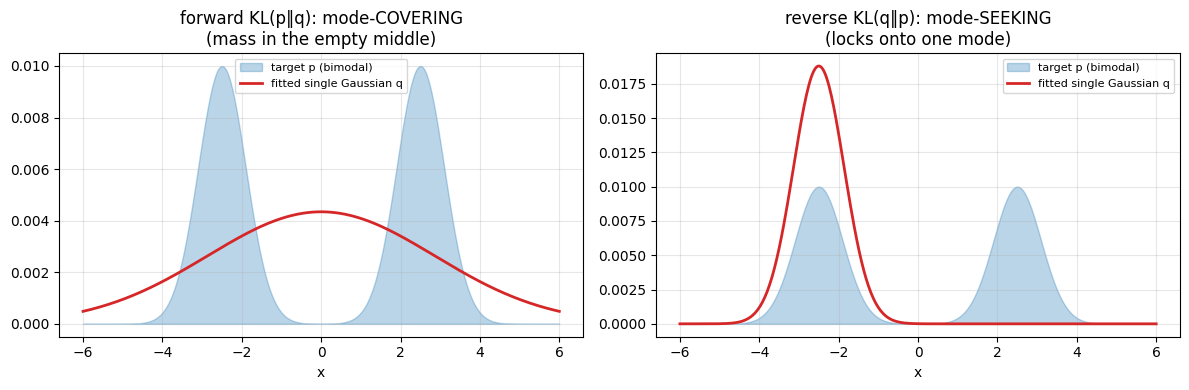

In [5]:
xs = np.linspace(-6,6,400)
def g(x,mu,s): return np.exp(-(x-mu)**2/(2*s**2))/np.sqrt(2*np.pi*s**2)
p = 0.5*g(xs,-2.5,0.6) + 0.5*g(xs,2.5,0.6); p/=p.sum()      # bimodal target
# fit a single Gaussian q by scanning mean/std, minimizing each KL direction
def fit(direction):
    best=None
    for mu in np.linspace(-3,3,61):
        for s in np.linspace(0.4,3.5,40):
            q=g(xs,mu,s); q/=q.sum()
            d = kl(p,q) if direction=="forward" else kl(q,p)
            if best is None or d<best[0]: best=(d,mu,s)
    _,mu,s = best; q=g(xs,mu,s); q/=q.sum(); return q
qf, qr = fit("forward"), fit("reverse")
fig, ax = plt.subplots(1,2,figsize=(12,4))
for a,(q,title) in zip(ax,[(qf,"forward KL(p‖q): mode-COVERING\n(mass in the empty middle)"),(qr,"reverse KL(q‖p): mode-SEEKING\n(locks onto one mode)")]):
    a.fill_between(xs,p,alpha=0.3,color="tab:blue",label="target p (bimodal)")
    a.plot(xs,q,color="tab:red",lw=2,label="fitted single Gaussian q")
    a.set_title(title); a.set_xlabel("x"); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** Same target, same model family, opposite results — purely from KL direction. Forward KL (left) can't leave any mode uncovered, so it smears across both (the "blurry VAE sample" phenomenon). Reverse KL (right) commits to one mode (the "mode collapse" phenomenon). This asymmetry is a genuinely useful thing to know cold.

**↳ Used in:** why VAE samples are blurry (NB23), why GANs mode-collapse (NB24), and the KL direction choice in RLHF/variational methods (NB21).


## 5. Perplexity & a note on mutual information

**Perplexity** = $e^{\text{cross-entropy}}$ (in nats) — the standard way language-model quality is reported. Intuitively it's the *effective number of equally-likely choices* the model is deciding among per token: perplexity 1 = perfect, perplexity = vocab size = random guessing. Our GPT (NB11) reached ~1.56 nats/char → perplexity $e^{1.56}\approx 4.8$ (as if choosing among ~5 characters, vs 65 random).

**Mutual information** $I(X;Y) = H(X) - H(X|Y)$ measures how much knowing $Y$ reduces uncertainty about $X$ — the information *shared* between two variables. It's the basis of **contrastive learning** (InfoNCE, CLIP NB40) and representation-learning objectives.


In [6]:
for ce in [1.56, 2.3, np.log(65)]:
    print(f"cross-entropy {ce:.3f} nats  ->  perplexity {np.exp(ce):.1f}"
          + ("   (our char-GPT, NB11)" if abs(ce-1.56)<0.01 else "   (random over 65 chars)" if ce>4 else ""))
print("\nLower perplexity = the model is 'less perplexed' = fewer effective choices per token.")


cross-entropy 1.560 nats  ->  perplexity 4.8   (our char-GPT, NB11)
cross-entropy 2.300 nats  ->  perplexity 10.0
cross-entropy 4.174 nats  ->  perplexity 65.0   (random over 65 chars)

Lower perplexity = the model is 'less perplexed' = fewer effective choices per token.


## What you learned
- **Entropy** $H(p)=-\sum p\log p$: average surprise / irreducible uncertainty (the loss floor).
- **Cross-entropy** $H(p,q)$: the classification/LM loss; $\ge H(p)$, equal iff $q=p$.
- **KL divergence** $D(p\|q)=H(p,q)-H(p)\ge 0$: the "distance" between distributions; minimizing CE = minimizing KL = matching the data.
- **Forward vs reverse KL**: mode-covering (blurry) vs mode-seeking (collapse).
- **Perplexity** = $e^{\text{CE}}$; **mutual information** for contrastive learning.

## Exercises
1. **CE = H + KL.** Prove the decomposition and explain why minimizing CE minimizes KL(p‖q).
2. **Gibbs' inequality.** Prove $D_{\mathrm{KL}}\ge 0$ (hint: Jensen's inequality on the convex $-\log$).
3. **Gaussian KL.** Derive the closed-form $D_{\mathrm{KL}}(\mathcal{N}(\mu,\sigma^2)\|\mathcal{N}(0,1))$ used in the VAE (NB23).
4. **Label smoothing.** Show label smoothing (NB09) is cross-entropy against a softened target distribution; what's its entropy?
5. **Perplexity of your GPT.** Compute the perplexity of the trained GPT (NB11) and interpret it.
6. **InfoNCE.** Read how the contrastive InfoNCE loss bounds mutual information (preview of CLIP, NB40).

## 📚 References & further reading
- **A Mathematical Theory of Communication** — Shannon (1948). The founding paper of information theory.
- **Deep Learning** — Goodfellow, Bengio & Courville (2016), Chapter 3.13 ("Information Theory").
- **Information Theory, Inference, and Learning Algorithms** — MacKay (2003, free online). The best ML-oriented treatment.
- **Elements of Information Theory** — Cover & Thomas. The standard reference.

---
**Next:** *Prerequisites · M5 — Optimization & numerical methods*: gradient descent as optimization, convexity, condition number, second-order methods, and floating-point pitfalls — bridging the math to the optimizers (NB04) and numerics (NB15).
